# Phase 6 - Model Evaluation

In [1]:
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

In [2]:
def evaluate_phase6(model, history, model_name, X_test_padded, y_test, X_test_reviews, output_dir="phase6_results"):

    # output folder
    model_dir = os.path.join(output_dir, model_name.replace(" ", "_"))

    os.makedirs(model_dir, exist_ok=True)

    # input shape
    print("\n" + "=" * 60)
    print(f"PHASE 6 - {model_name}")
    print("=" * 60)

    print("Model input shape :", X_test_padded.shape)
    print("Test labels shape :", np.asarray(y_test).shape)
    print("Test reviews shape:", np.asarray(X_test_reviews).shape)

    # Make sure all lengths match
    if len(X_test_padded) != len(y_test):
        raise ValueError(
            "X_test_padded and y_test have different lengths."
        )

    if len(X_test_reviews) != len(y_test):
        raise ValueError(
            "X_test_reviews and y_test have different lengths."
        )

    
    # predictions
    probabilities = model.predict(X_test_padded, batch_size=128, verbose=1).ravel()
    predictions = (probabilities >= 0.5).astype(int)

    print("\nPrediction shape:", probabilities.shape)

    # metrics
    accuracy = accuracy_score(y_test, predictions)
    precision_value = precision_score(y_test, predictions, zero_division=0)
    recall_value = recall_score(y_test, predictions, zero_division=0)
    f1_value = f1_score(y_test, predictions, zero_division=0)
    roc_auc = roc_auc_score(y_test, probabilities)
    average_precision = average_precision_score(y_test, probabilities)

    # confusion matrix
    cm = confusion_matrix(y_test, predictions)
    tn, fp, fn, tp = cm.ravel()

    print("\n")
    print(f"{model_name} RESULTS")
    print("\n")


    print(f"Accuracy          : {accuracy:.5f}")
    print(f"Precision         : {precision_value:.5f}")
    print(f"Recall            : {recall_value:.5f}")
    print(f"F1 Score          : {f1_value:.5f}")
    print(f"ROC-AUC           : {roc_auc:.5f}")
    print(f"Average Precision : {average_precision:.5f}")

    print("\nConfusion Matrix")
    print("-" * 40)
    print(cm)

    print("\nTN:", tn)
    print("FP:", fp)
    print("FN:", fn)
    print("TP:", tp)

    
    # training vs val accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(history["accuracy"], label="Training Accuracy")
    plt.plot(history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} - Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join( model_dir,"training_validation_accuracy.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    
    # training vs validation loss
    plt.figure(figsize=(8, 5))
    plt.plot(history["loss"], label="Training Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig( os.path.join(model_dir, "training_validation_loss.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"]).plot(ax=ax)
    ax.set_title(f"{model_name} - Confusion Matrix")
    plt.savefig(os.path.join(model_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # roc curve
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(model_dir, "roc_curve.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # precision recall curve
    pr_precision, pr_recall, _ = precision_recall_curve(y_test, probabilities)
    plt.figure(figsize=(8, 6))
    plt.plot(pr_recall, pr_precision, label=f"{model_name} (AP = {average_precision:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(model_dir, "precision_recall_curve.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # Miss classified reviews
    
    y_test_array = np.asarray(y_test).reshape(-1)
    reviews_array = np.asarray(X_test_reviews).reshape(-1)
    misclassified_mask = (y_test_array != predictions)

    misclassified = pd.DataFrame({
        "review": reviews_array,
        "actual": y_test_array,
        "predicted": predictions,
        "probability": probabilities
    })

    misclassified = misclassified[misclassified_mask].reset_index(drop=True)
    misclassified["actual_sentiment"] = (misclassified["actual"].map({
            0: "Negative",
            1: "Positive"
        })
    )

    misclassified["predicted_sentiment"] = (misclassified["predicted"]
        .map({
            0: "Negative",
            1: "Positive"
        })
    )

    # save missclassified reviews
    misclassified.to_csv(os.path.join(model_dir, "misclassified_reviews.csv"), index=False)
    print("\nTotal misclassified:",len(misclassified))

    # missclassified counts
    false_positive_count = np.sum((y_test_array == 0) & (predictions == 1))
    false_negative_count = np.sum((y_test_array == 1) & (predictions == 0))
    print("False Positives:", false_positive_count)
    print("False Negatives:", false_negative_count)

    # visual for misclassifyy
    plt.figure(figsize=(7, 5))
    values = [false_positive_count, false_negative_count]
    labels = ["False Positive", "False Negative"]
    plt.bar( labels, values)
    plt.title(f"{model_name} - Misclassified Reviews")
    plt.xlabel( "Error Type")
    plt.ylabel("Number of Reviews")
    for i, value in enumerate(values):
        plt.text(
            i,
            value + 5,
            str(value),
            ha="center"
        )
    plt.grid(axis="y")
    plt.savefig(os.path.join(model_dir, "misclassified_reviews.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # dis sample missclasssified reviews
    print("\nSample Misclassified Reviews")
    print("-" * 60)

    display(
        misclassified[
            [
                "review",
                "actual_sentiment",
                "predicted_sentiment",
                "probability"
            ]
        ].head(10)
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision_value,
        "Recall": recall_value,
        "F1 Score": f1_value,
        "ROC-AUC": roc_auc,
        "Average Precision": average_precision,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp,
        "Misclassified": len(misclassified),
        "Confusion Matrix": cm,
        "Probabilities": probabilities,
        "Predictions": predictions,
        "Misclassified Reviews": misclassified
    }

### ANN

In [4]:
processed_df = pd.read_csv("../processed_data/imdb_cleaned.csv")

In [5]:
from sklearn.model_selection import train_test_split

X = processed_df["clean_review"]
y = processed_df["label"]

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val_text, X_test_reviews, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("X_test_reviews:", X_test_reviews.shape)
print("y_test:", y_test.shape)

X_test_reviews: (4959,)
y_test: (4959,)


In [14]:
import os

print(os.listdir("models2"))

['.ipynb_checkpoints', 'ann_model_comparison.csv', 'best_ann_batch128 (1).keras', 'best_ann_batch128_training_history (1).csv', 'bilstm_model_comparison.csv', 'bilstm_rmsprop_best.keras', 'bilstm_rmsprop_training_history.csv', 'gru_final_90.keras', 'gru_model_comparison.csv', 'lstm_model_comparison.csv', 'lstm_reducelr_best.keras', 'lstm_reducelr_history.pkl', 'phase6_ann_confusion_matrix.png', 'phase6_ann_misclassified_reviews.csv', 'phase6_ann_misclassified_reviews.png', 'rnn_batch128.keras', 'rnn_batch128_training_history.csv', 'rnn_model_comparison.csv']


In [12]:
import pickle

with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 90662


In [13]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_test_seq = tokenizer.texts_to_sequences(
    X_test_reviews
)

X_test_padded = pad_sequences(
    X_test_seq,
    maxlen=500,
    padding="post",
    truncating="post"
)

print("X_test_padded:", X_test_padded.shape)

X_test_padded: (4959, 500)


## 1.ANN

In [15]:
ann_model = tf.keras.models.load_model("models2/best_ann_batch128 (1).keras")
ann_history = pd.read_csv("models2/best_ann_batch128_training_history (1).csv")


PHASE 6 - ANN Batch 128
Model input shape : (4959, 500)
Test labels shape : (4959,)
Test reviews shape: (4959,)
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step

Prediction shape: (4959,)


ANN Batch 128 RESULTS


Accuracy          : 0.89736
Precision         : 0.90707
Recall            : 0.88630
F1 Score          : 0.89657
ROC-AUC           : 0.95759
Average Precision : 0.95187

Confusion Matrix
----------------------------------------
[[2244  226]
 [ 283 2206]]

TN: 2244
FP: 226
FN: 283
TP: 2206


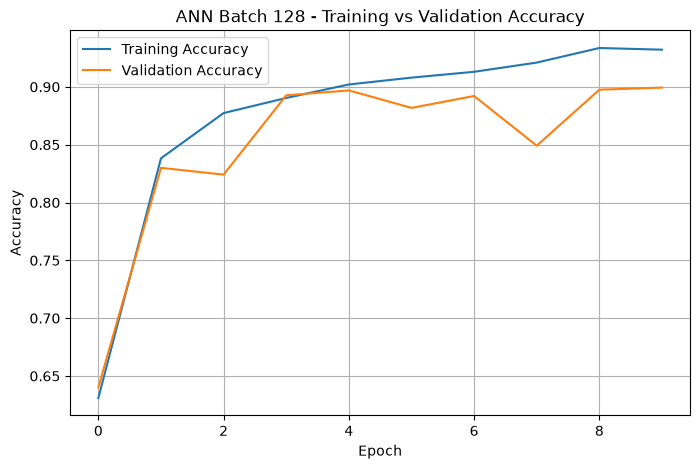

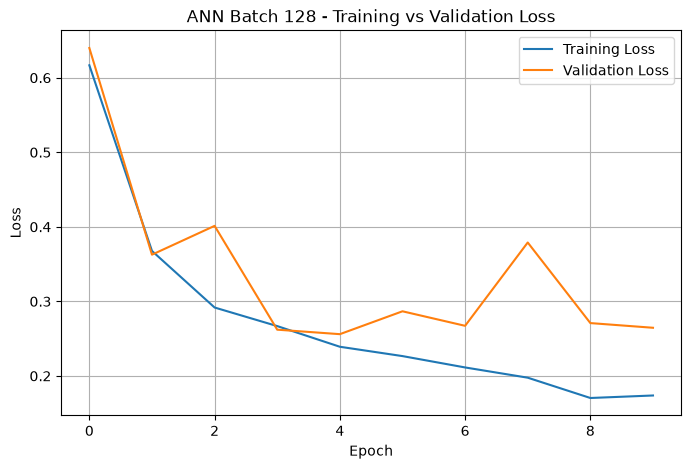

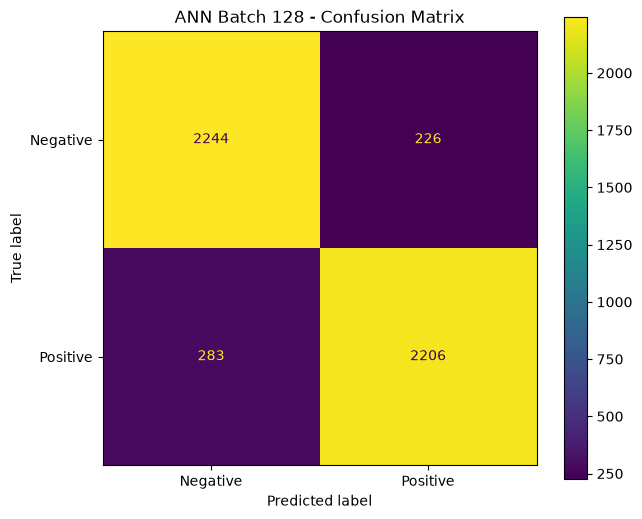

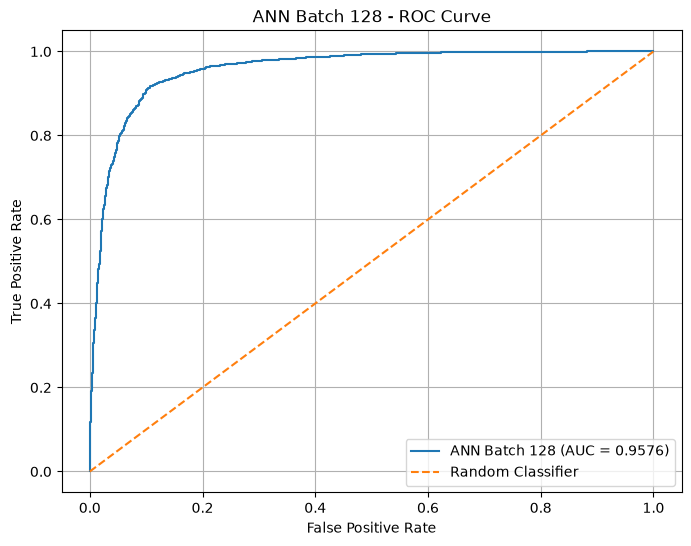

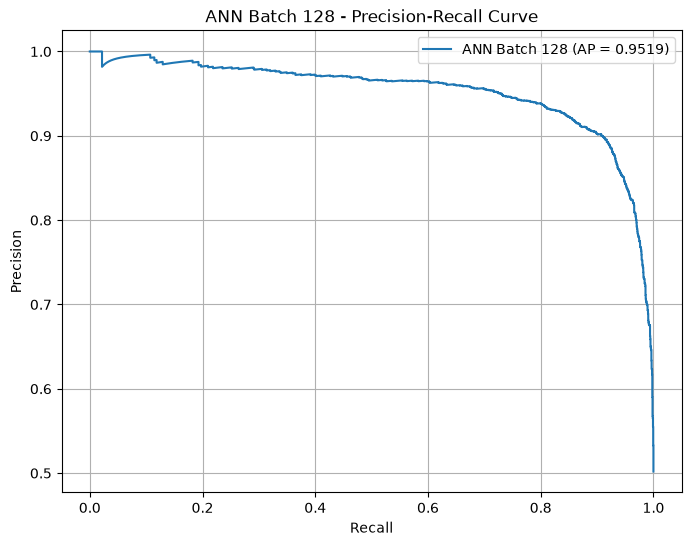


Total misclassified: 509
False Positives: 226
False Negatives: 283


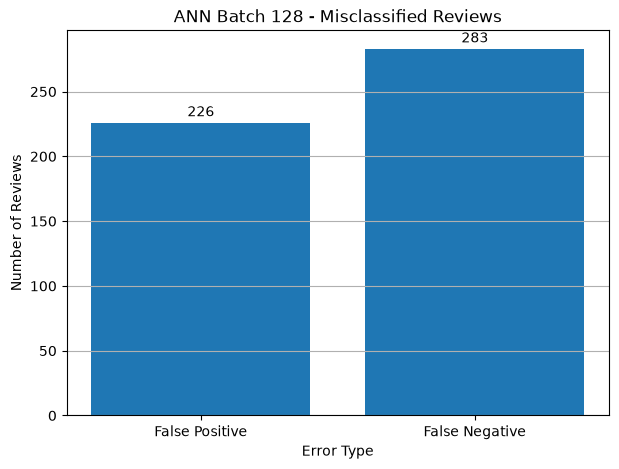


Sample Misclassified Reviews
------------------------------------------------------------


,review,actual_sentiment,predicted_sentiment,probability
0,this silly movie is really fun for the younger...,Positive,Negative,0.327565
1,we have to remember that the s were practicall...,Positive,Negative,0.037879
2,this episode of twilight zone combines a silen...,Positive,Negative,0.499164
3,hollow man starts as brilliant but flawed scie...,Positive,Negative,0.350916
4,saw this for the first time on uk tv with good...,Positive,Negative,0.316417
5,brian de palma s undeniable virtuosity can t r...,Positive,Negative,0.329915
6,a well made run of the mill movie with a tragi...,Positive,Negative,0.476832
7,i am normally not compelled to write a review ...,Positive,Negative,0.028472
8,for those who like depressing films with sleaz...,Negative,Positive,0.934426
9,i remember viewing this movie when i was a kid...,Negative,Positive,0.514796


In [16]:
ann_results = evaluate_phase6(
    model=ann_model,
    history=ann_history,
    model_name="ANN Batch 128",
    X_test_padded=X_test_padded,
    y_test=y_test,
    X_test_reviews=X_test_reviews
)

In [20]:
for key in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Average Precision"]:
    print(f"{key:20s}: "f"{ann_results[key]:.5f}")

Accuracy            : 0.89736
Precision           : 0.90707
Recall              : 0.88630
F1 Score            : 0.89657
ROC-AUC             : 0.95759
Average Precision   : 0.95187


## 2. RNN

In [17]:
rnn_model = tf.keras.models.load_model("models2/rnn_batch128.keras")
rnn_history = pd.read_csv("models2/rnn_batch128_training_history.csv")



PHASE 6 - RNN Batch 128
Model input shape : (4959, 500)
Test labels shape : (4959,)
Test reviews shape: (4959,)
39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 389ms/step

Prediction shape: (4959,)


RNN Batch 128 RESULTS


Accuracy          : 0.50716
Precision         : 0.50913
Recall            : 0.50422
F1 Score          : 0.50666
ROC-AUC           : 0.50967
Average Precision : 0.51400

Confusion Matrix
----------------------------------------
[[1260 1210]
 [1234 1255]]

TN: 1260
FP: 1210
FN: 1234
TP: 1255


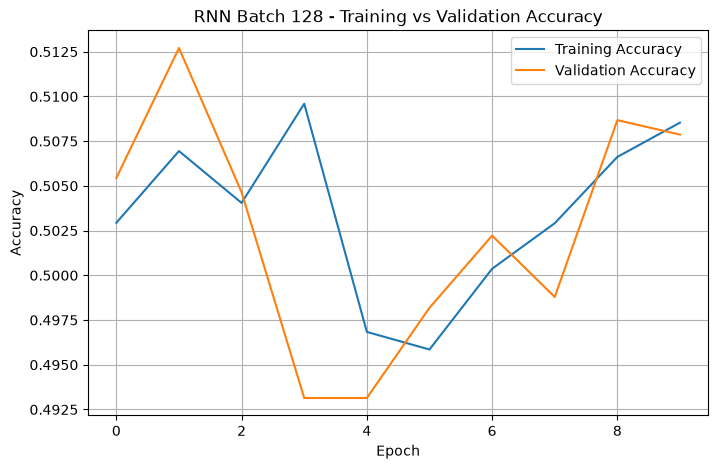

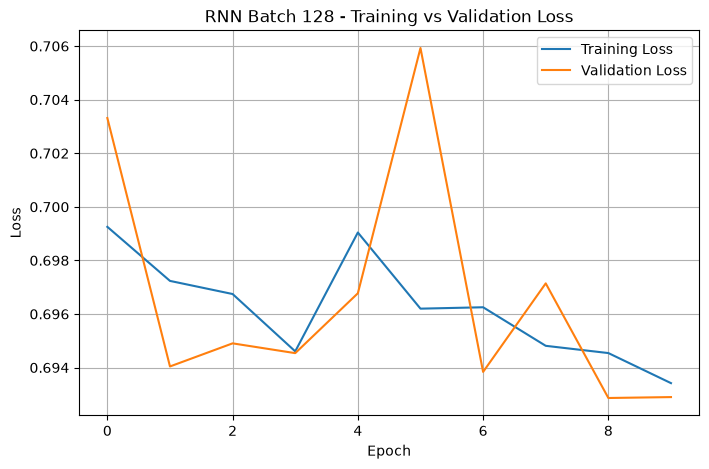

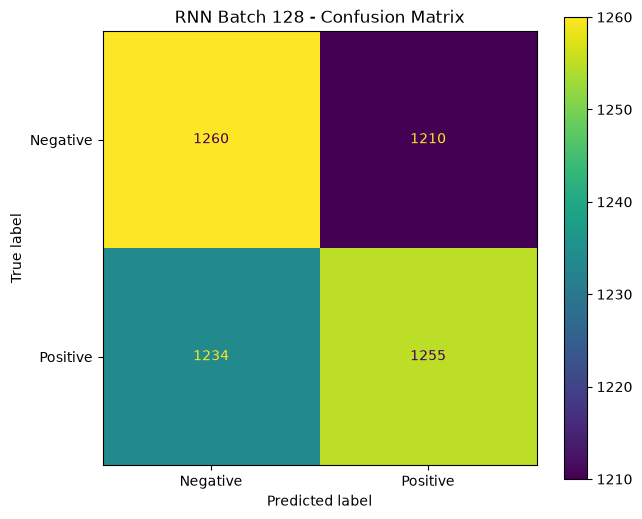

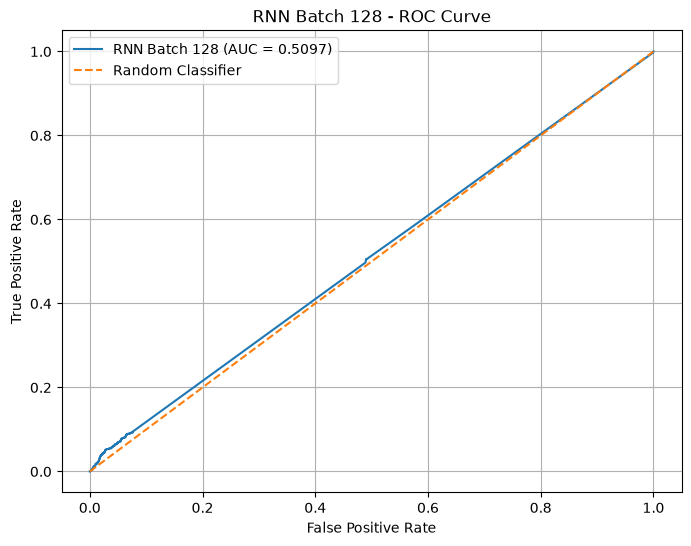

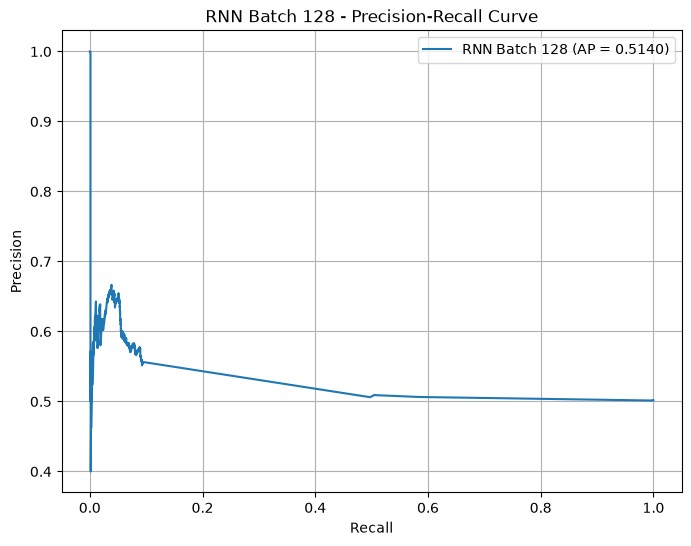


Total misclassified: 2444
False Positives: 1210
False Negatives: 1234


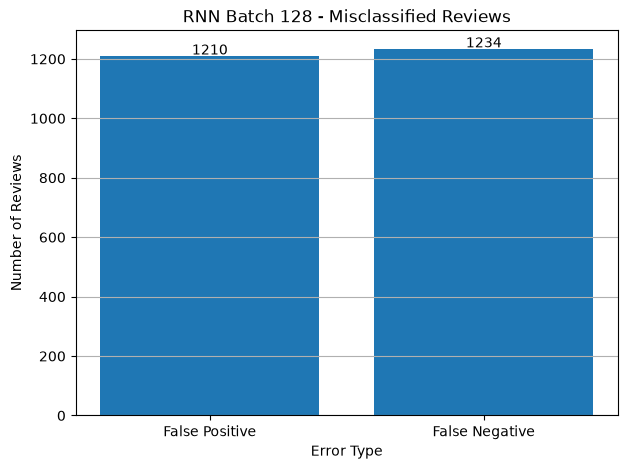


Sample Misclassified Reviews
------------------------------------------------------------


,review,actual_sentiment,predicted_sentiment,probability
0,lost isn t the greatest tv show in history but...,Positive,Negative,0.495461
1,this is another bollywood remake of a hollywoo...,Negative,Positive,0.522336
2,this is an admirable attempt from first time f...,Negative,Positive,0.522336
3,we have to remember that the s were practicall...,Positive,Negative,0.495461
4,i ve seen some bad things in my time a half de...,Negative,Positive,0.522336
5,well i do disagreed with the other comment pos...,Positive,Negative,0.495461
6,shame is a swedish film in swedish with englis...,Positive,Negative,0.495461
7,ranma is my favorite anime by rumiko takahashi...,Positive,Negative,0.495461
8,saw this for the first time on uk tv with good...,Positive,Negative,0.495461
9,mr blandings builds his dream house may be the...,Positive,Negative,0.495461


In [18]:
rnn_results = evaluate_phase6(
    model=rnn_model,
    history=rnn_history,
    model_name="RNN Batch 128",
    X_test_padded=X_test_padded,
    y_test=y_test,
    X_test_reviews=X_test_reviews
)

In [19]:
for key in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Average Precision"]:
    print(f"{key:20s}: "f"{rnn_results[key]:.5f}")

Accuracy            : 0.50716
Precision           : 0.50913
Recall              : 0.50422
F1 Score            : 0.50666
ROC-AUC             : 0.50967
Average Precision   : 0.51400


## 3. LSTM

In [21]:
lstm_model = tf.keras.models.load_model("models2/lstm_reducelr_best.keras")

with open("models2/lstm_reducelr_history.pkl", "rb") as f:
    lstm_history = pickle.load(f)


PHASE 6 - LSTM ReduceLR
Model input shape : (4959, 500)
Test labels shape : (4959,)
Test reviews shape: (4959,)
39/39 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step

Prediction shape: (4959,)


LSTM ReduceLR RESULTS


Accuracy          : 0.88425
Precision         : 0.88531
Recall            : 0.88389
F1 Score          : 0.88460
ROC-AUC           : 0.94395
Average Precision : 0.93548

Confusion Matrix
----------------------------------------
[[2185  285]
 [ 289 2200]]

TN: 2185
FP: 285
FN: 289
TP: 2200


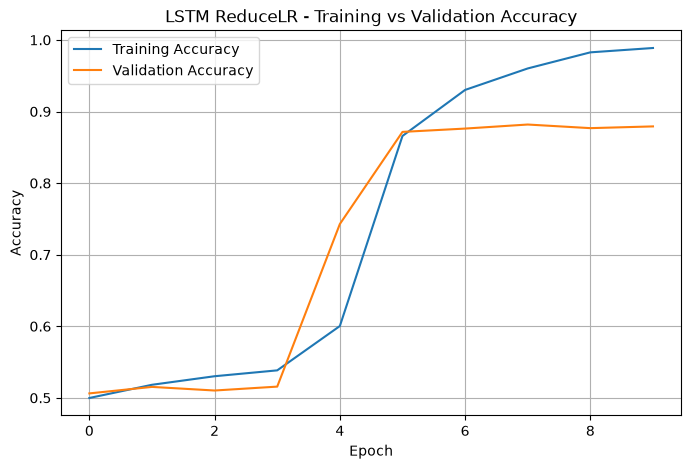

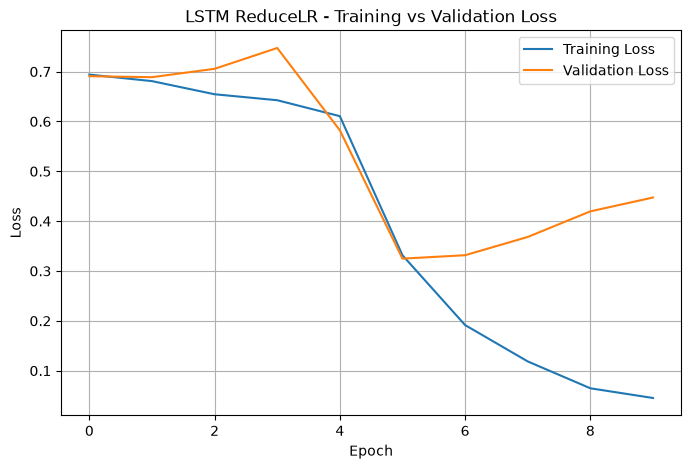

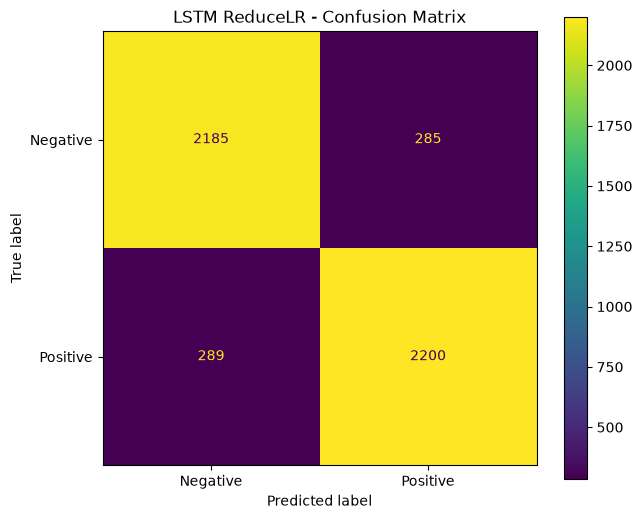

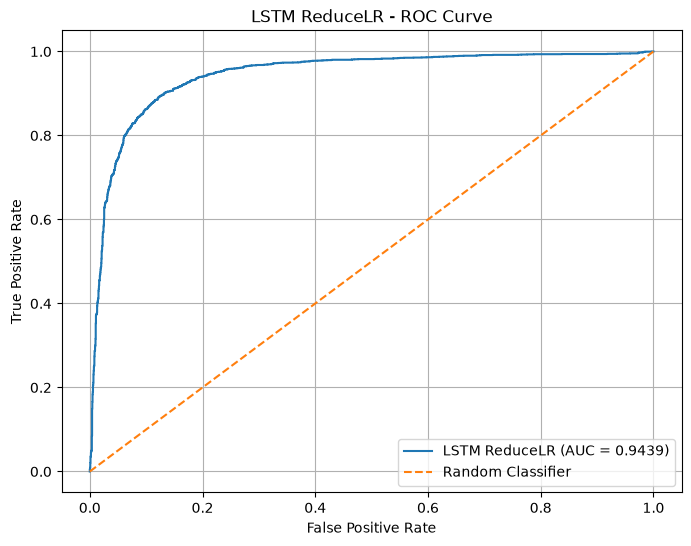

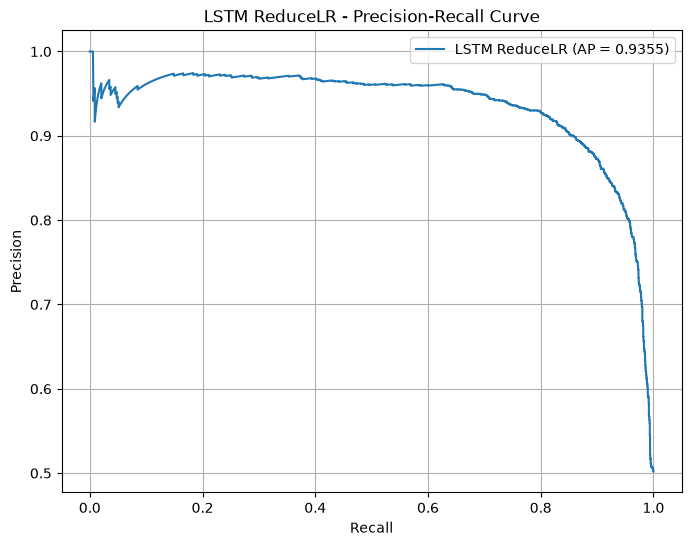


Total misclassified: 574
False Positives: 285
False Negatives: 289


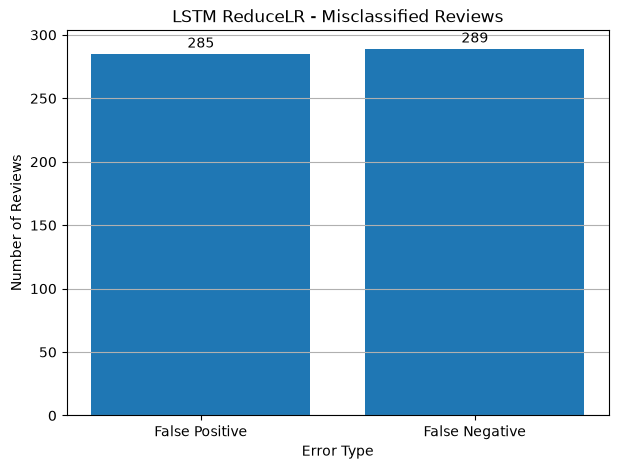


Sample Misclassified Reviews
------------------------------------------------------------


,review,actual_sentiment,predicted_sentiment,probability
0,this silly movie is really fun for the younger...,Positive,Negative,0.259827
1,we have to remember that the s were practicall...,Positive,Negative,0.010502
2,this episode of twilight zone combines a silen...,Positive,Negative,0.002208
3,i only gave this nine stars instead of ten bec...,Positive,Negative,0.071384
4,brian de palma s undeniable virtuosity can t r...,Positive,Negative,0.017665
5,probably the best horror movie in years there ...,Positive,Negative,0.274380
6,a well made run of the mill movie with a tragi...,Positive,Negative,0.120387
7,for those who like depressing films with sleaz...,Negative,Positive,0.998211
8,when a hardworking entrepreneur is rejected fr...,Negative,Positive,0.719583
9,i remember viewing this movie when i was a kid...,Negative,Positive,0.898811


In [22]:
lstm_results = evaluate_phase6(
    model=lstm_model,
    history=lstm_history,
    model_name="LSTM ReduceLR",
    X_test_padded=X_test_padded,
    y_test=y_test,
    X_test_reviews=X_test_reviews
)

In [23]:
for key in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Average Precision"]:
    print(f"{key:20s}: "f"{lstm_results[key]:.5f}")

Accuracy            : 0.88425
Precision           : 0.88531
Recall              : 0.88389
F1 Score            : 0.88460
ROC-AUC             : 0.94395
Average Precision   : 0.93548


## 4. Bi-LSTM

In [24]:
bilstm_model = tf.keras.models.load_model("models2/bilstm_rmsprop_best.keras")
bilstm_history = pd.read_csv("models2/bilstm_rmsprop_training_history.csv")


PHASE 6 - Bi-LSTM RMSprop
Model input shape : (4959, 500)
Test labels shape : (4959,)
Test reviews shape: (4959,)
39/39 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step

Prediction shape: (4959,)


Bi-LSTM RMSprop RESULTS


Accuracy          : 0.89635
Precision         : 0.91094
Recall            : 0.87947
F1 Score          : 0.89493
ROC-AUC           : 0.95005
Average Precision : 0.94631

Confusion Matrix
----------------------------------------
[[2256  214]
 [ 300 2189]]

TN: 2256
FP: 214
FN: 300
TP: 2189


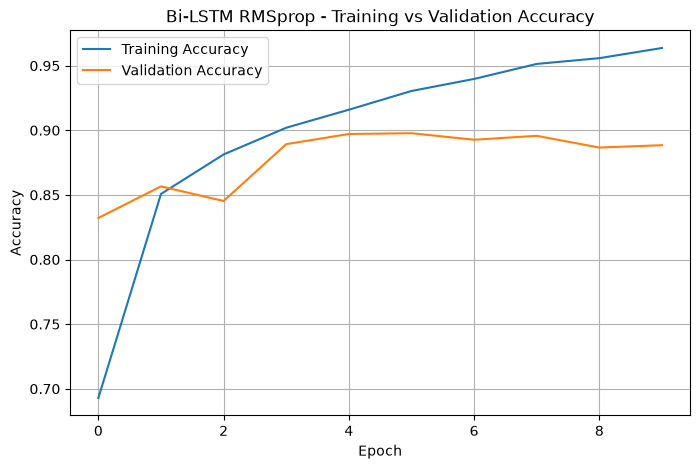

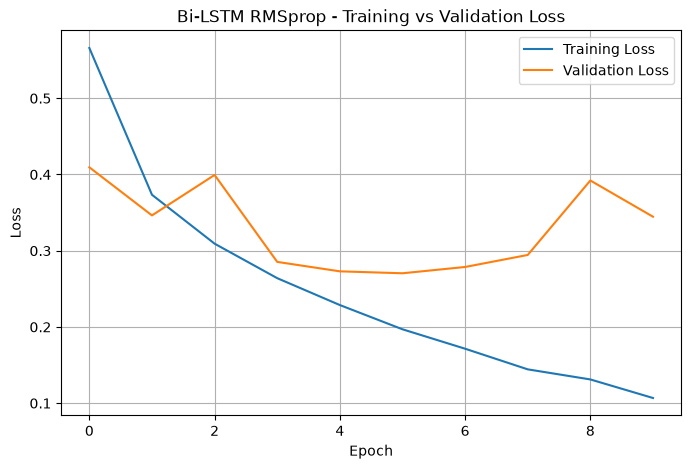

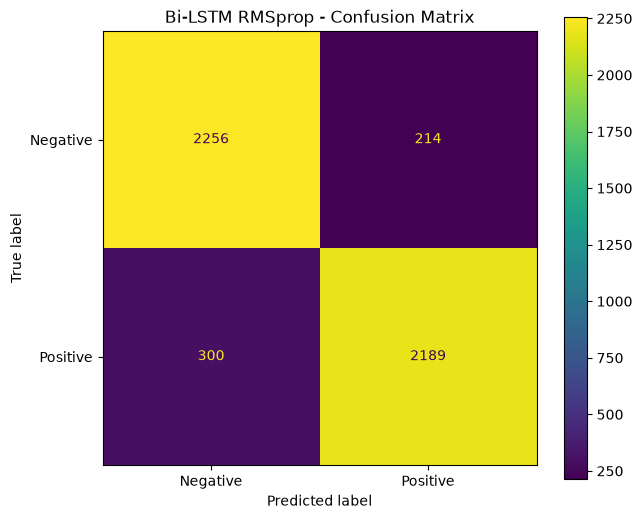

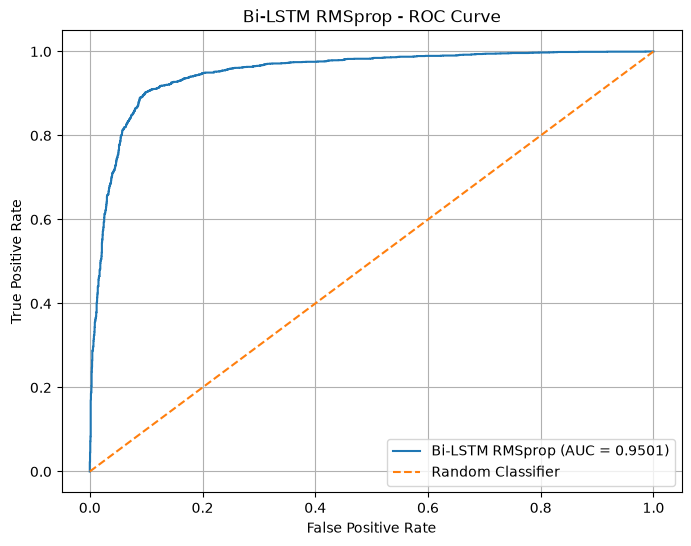

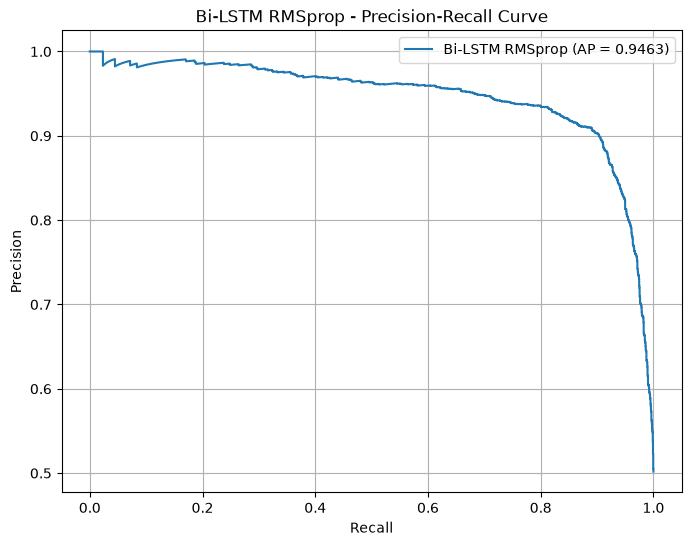


Total misclassified: 514
False Positives: 214
False Negatives: 300


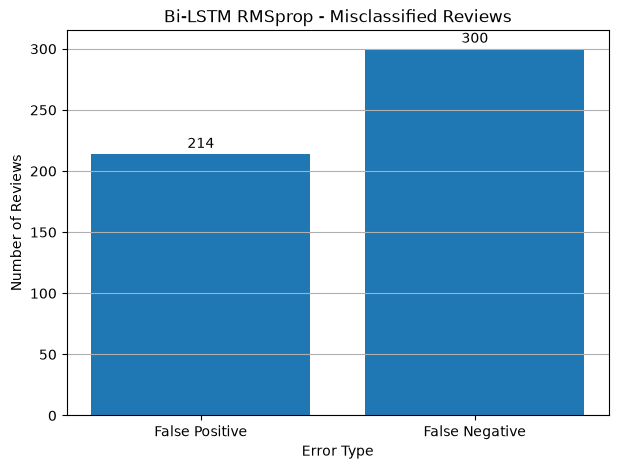


Sample Misclassified Reviews
------------------------------------------------------------


,review,actual_sentiment,predicted_sentiment,probability
0,we have to remember that the s were practicall...,Positive,Negative,0.007183
1,when the film started i got the feeling this w...,Negative,Positive,0.891192
2,hollow man starts as brilliant but flawed scie...,Positive,Negative,0.052773
3,saw this for the first time on uk tv with good...,Positive,Negative,0.359366
4,attention spoiler many people told me that pla...,Positive,Negative,0.006985
5,just to mention one more thing about gentleman...,Positive,Negative,0.109570
6,i am normally not compelled to write a review ...,Positive,Negative,0.009090
7,for those who like depressing films with sleaz...,Negative,Positive,0.998705
8,i remember viewing this movie when i was a kid...,Negative,Positive,0.935098
9,tromeo juliet th anniversary edition william s...,Positive,Negative,0.339255


In [25]:
bilstm_results = evaluate_phase6(
    model=bilstm_model,
    history=bilstm_history,
    model_name="Bi-LSTM RMSprop",
    X_test_padded=X_test_padded,
    y_test=y_test,
    X_test_reviews=X_test_reviews
)

In [26]:
for key in ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Average Precision"]:
    print(f"{key:20s}: "f"{bilstm_results[key]:.5f}")

Accuracy            : 0.89635
Precision           : 0.91094
Recall              : 0.87947
F1 Score            : 0.89493
ROC-AUC             : 0.95005
Average Precision   : 0.94631


## 5. GRU

In [27]:
gru_model = tf.keras.models.load_model("models2/gru_final_90.keras")
gru_history = pd.read_csv("models2/gru_final_90_training_history.csv")

In [ ]:
gru_comparison = pd.read_csv(
    "models2/gru_model_comparison.csv"
)

display(gru_comparison)


PHASE 6 - GRU LR
Model input shape : (4959, 500)
Test labels shape : (4959,)
Test reviews shape: (4959,)
39/39 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step

Prediction shape: (4959,)


GRU LR RESULTS


Accuracy          : 0.90018
Precision         : 0.88405
Recall            : 0.92206
F1 Score          : 0.90265
ROC-AUC           : 0.95607
Average Precision : 0.94124

Confusion Matrix
----------------------------------------
[[2169  301]
 [ 194 2295]]

TN: 2169
FP: 301
FN: 194
TP: 2295


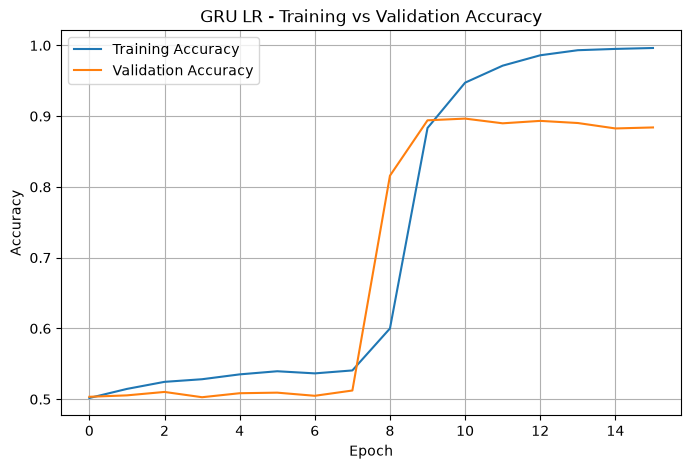

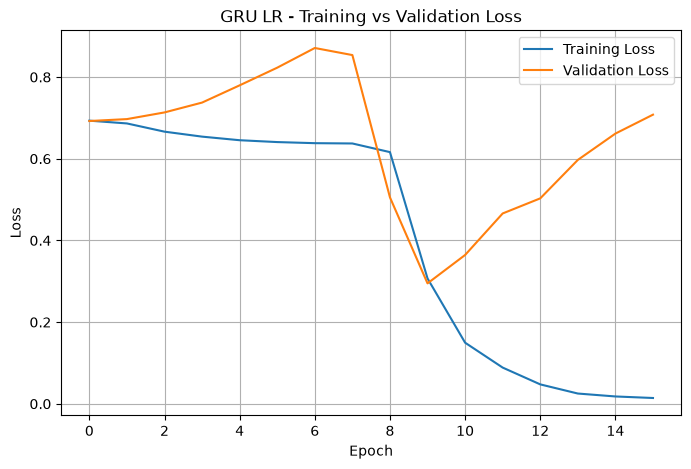

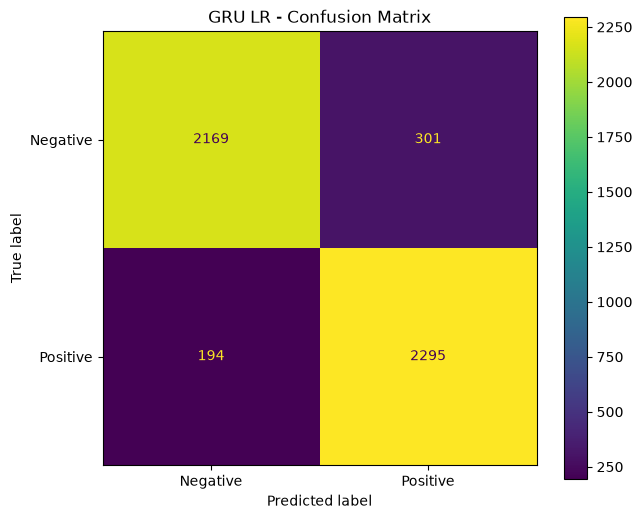

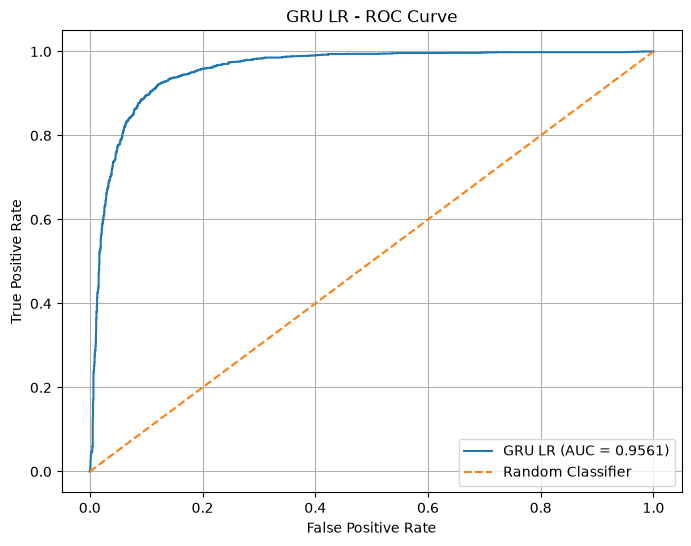

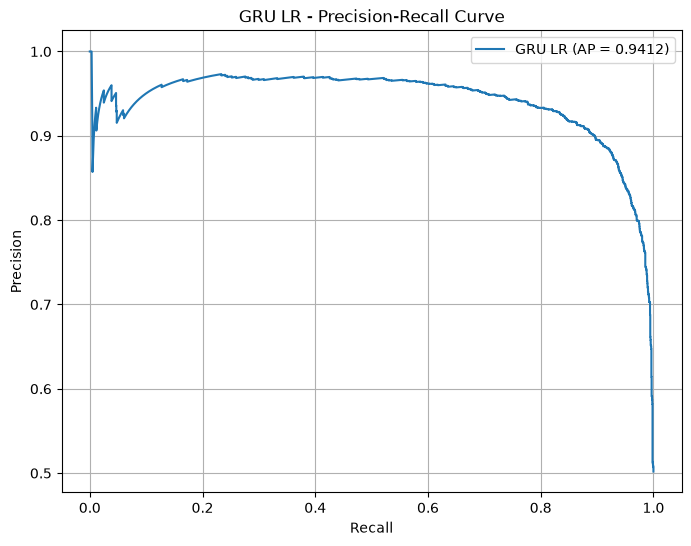


Total misclassified: 495
False Positives: 301
False Negatives: 194


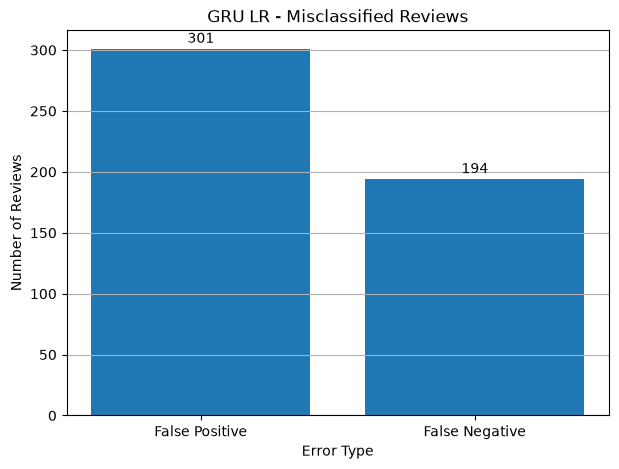


Sample Misclassified Reviews
------------------------------------------------------------


,review,actual_sentiment,predicted_sentiment,probability
0,this silly movie is really fun for the younger...,Positive,Negative,0.095128
1,we have to remember that the s were practicall...,Positive,Negative,0.020531
2,brian de palma s undeniable virtuosity can t r...,Positive,Negative,0.300118
3,probably the best horror movie in years there ...,Positive,Negative,0.379023
4,this is a formula b science fiction movie and ...,Negative,Positive,0.541128
5,for those who like depressing films with sleaz...,Negative,Positive,0.988761
6,when a hardworking entrepreneur is rejected fr...,Negative,Positive,0.950862
7,i remember viewing this movie when i was a kid...,Negative,Positive,0.866833
8,kim basinger and mickey rourke star in this co...,Negative,Positive,0.972258
9,tromeo juliet th anniversary edition william s...,Positive,Negative,0.147772


In [30]:
gru_results = evaluate_phase6(
    model=gru_model,
    history=gru_history,
    model_name="GRU LR",
    X_test_padded=X_test_padded,
    y_test=y_test,
    X_test_reviews=X_test_reviews
)

In [32]:
# store all
phase6_results = [

    {
        "Model": "GRU Adam LR 0.0005",
        "Accuracy": 0.90018,
        "Precision": 0.88405,
        "Recall": 0.92206,
        "F1 Score": 0.90265,
        "ROC-AUC": 0.95607,
        "Average Precision": 0.94124
    },

    {
        "Model": "ANN Batch 128",
        "Accuracy": 0.89736,
        "Precision": 0.90707,
        "Recall": 0.88630,
        "F1 Score": 0.89657,
        "ROC-AUC": 0.95759,
        "Average Precision": 0.95187
    },

    {
        "Model": "Bi-LSTM RMSprop",
        "Accuracy": 0.89635,
        "Precision": 0.91094,
        "Recall": 0.87947,
        "F1 Score": 0.89493,
        "ROC-AUC": 0.95005,
        "Average Precision": 0.94631
    },

    {
        "Model": "LSTM ReduceLR",
        "Accuracy": 0.88425,
        "Precision": 0.88531,
        "Recall": 0.88389,
        "F1 Score": 0.88460,
        "ROC-AUC": 0.94395,
        "Average Precision": 0.93548
    },

    {
        "Model": "RNN Batch 128",
        "Accuracy": 0.50716,
        "Precision": 0.50913,
        "Recall": 0.50422,
        "F1 Score": 0.50666,
        "ROC-AUC": 0.50967,
        "Average Precision": 0.51400
    }
]

In [40]:
phase6_df = pd.DataFrame(phase6_results)
phase6_results = phase6_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
phase6_results

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,1,GRU Adam LR 0.0005,0.90018,0.88405,0.92206,0.90265,0.95607,0.94124
1,2,ANN Batch 128,0.89736,0.90707,0.88630,0.89657,0.95759,0.95187
2,3,Bi-LSTM RMSprop,0.89635,0.91094,0.87947,0.89493,0.95005,0.94631
3,4,LSTM ReduceLR,0.88425,0.88531,0.88389,0.88460,0.94395,0.93548
4,5,RNN Batch 128,0.50716,0.50913,0.50422,0.50666,0.50967,0.51400


In [42]:
phase6_results.to_csv("../models/final_model_comparison.csv", index=False)
print("saved")

saved
